# Image and EDS Point Spectra

Acquire an image and collect EDS spectra at selected beam positions.


### Run the servers

Make sure you are on the VPN and the AutoScript server is running. Then start the asyncroscopy Tango servers from the repository root:

```bash
uv run startup_scripts/run_servers.py
```


### Imports


In [1]:
import os
import json
import time

import tango
import numpy as np
import matplotlib.pyplot as plt
from tiled.client import from_uri

import sidpy

%matplotlib ipympl


### Ping servers


In [3]:
DB_HOST = "10.46.217.241"
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

server_names = ['stage', 'scan', 'eds', 'camera', 'data', 'microscope']

scan = tango.DeviceProxy("asyncroscopy/scan/default")
microscope = tango.DeviceProxy("asyncroscopy/microscope/default")
data = tango.DeviceProxy("asyncroscopy/data/default")

for proxy in [scan, microscope, data]:
    proxy.set_timeout_millis(120_000)
    proxy.ping()
    print(proxy.name(), proxy.state())

asyncroscopy/scan/default ON
asyncroscopy/microscope/default ON
asyncroscopy/data/default ON


### Start Tiled data server


In [ ]:
config = json.loads(data.get_config())
config

{'host': '127.0.0.1',
 'port': 9091,
 'uri': 'http://127.0.0.1:9091',
 'save_path': 'outputs/tiled_acquisitions',
 'tiled_server': 'yes',
 'tiled_server_status': 'running; serving path; files register manually',
 'tiled_server_serving': 'outputs/tiled_acquisitions'}

In [ ]:
# Set the save path (or change it)
data.save_path = "D:/microscopedata/tiled/ahoust17/2026_05_29_test/"

In [ ]:
config = json.loads(data.get_config())
config

{'host': '127.0.0.1',
 'port': 9091,
 'uri': 'http://127.0.0.1:9091',
 'save_path': '/Users/austin/Desktop/new_tiled',
 'tiled_server': 'yes',
 'tiled_server_status': 'running; serving path; files register manually',
 'tiled_server_serving': '/Users/austin/Desktop/new_tiled'}

In [ ]:
client = from_uri(config.get("uri"))
print("Tiled keys:", list(client))

Tiled keys: []


### Acquire a reference image


In [5]:
scan.dwell_time = 1e-6
scan.imsize = 512
scan.scan_region = [0, 0, 1, 1]

print("dwell_time :", scan.dwell_time)
print("image size :", scan.imsize)
print("scan region:", list(scan.scan_region))


dwell_time : 1e-06
image size : 512
scan region: [np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(1.0)]


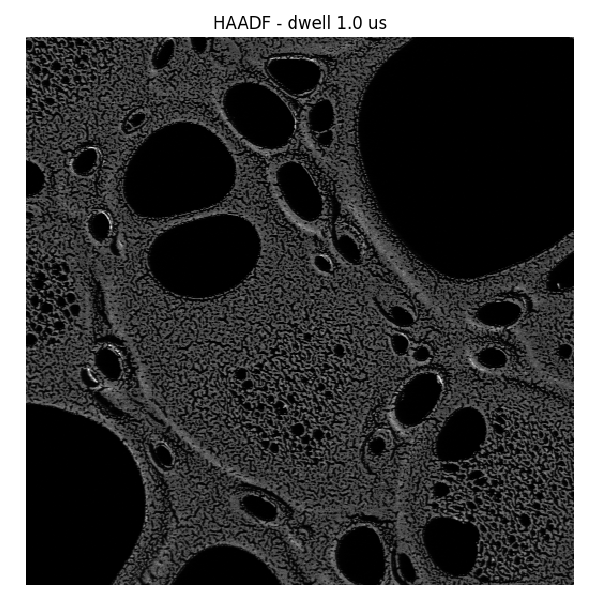

In [6]:
data_key = microscope.acquire_scanned_image(["haadf"])

image = client[data_key]["image"]["HAADF"].read()
metadata = dict(client[data_key]["image"]["HAADF"].metadata)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap="gray", interpolation="none")
ax.set_title(f"HAADF - dwell {scan.dwell_time * 1e6:.1f} us")
ax.axis("off")
plt.tight_layout()

### Choose random beam positions


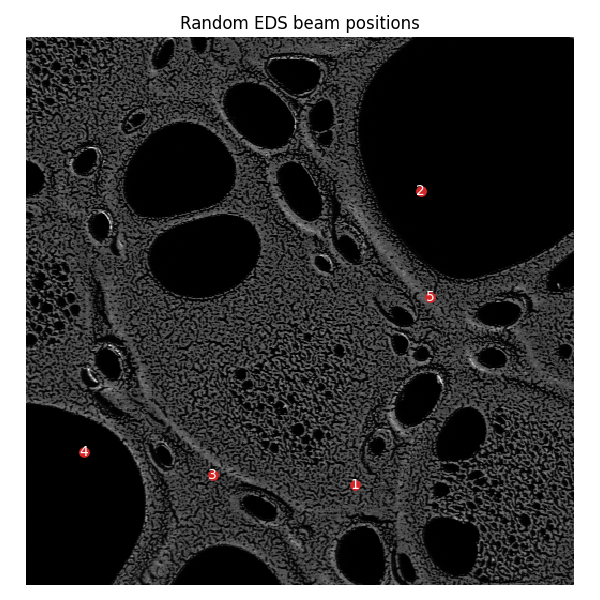

In [7]:
rng = np.random.default_rng(7)
n_points = 5
beam_points = rng.uniform(0.1, 0.9, size=(n_points, 2))

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap="gray", interpolation="none")
height, width = image.shape
ax.scatter(beam_points[:, 0] * (width - 1), beam_points[:, 1] * (height - 1), c="tab:red", s=45)
for index, (x_frac, y_frac) in enumerate(beam_points, start=1):
    ax.text(x_frac * (width - 1), y_frac * (height - 1), str(index), color="white", ha="center", va="center")
ax.set_title("Random EDS beam positions")
ax.axis("off")
plt.tight_layout()


### Place the beam and collect EDS spectra


In [8]:
spectra = []

for index, point in enumerate(beam_points, start=1):
    microscope.place_beam(point.tolist())
    key = microscope.acquire_spectrum("eds")
    node = client[key]["spectrum"]
    spectrum = np.squeeze(np.asarray(node.read()))
    metadata = dict(node.metadata)
    spectra.append({
        "point_index": index,
        "beam_position": point.tolist(),
        "tiled_key": key,
        "metadata": metadata,
        "spectrum": spectrum,
    })
    print(f"Point {index}: key={key}, beam={point.tolist()}, bins={spectrum.size}")


Point 1: key=spectrum_eds_20260529T123651510317.h5, beam=[0.6000763732837336, 0.8177710407756604], bins=4096
Point 2: key=spectrum_eds_20260529T123654037669.h5, beam=[0.7205485521961549, 0.2801657519924735], bins=4096
Point 3: key=spectrum_eds_20260529T123656665376.h5, beam=[0.34013302792898037, 0.7988427563170095], bins=4096
Point 4: key=spectrum_eds_20260529T123659470862.h5, beam=[0.10421224365245979, 0.756982734706213], bins=4096
Point 5: key=spectrum_eds_20260529T123702189341.h5, beam=[0.737655543001637, 0.47434796227497666], bins=4096


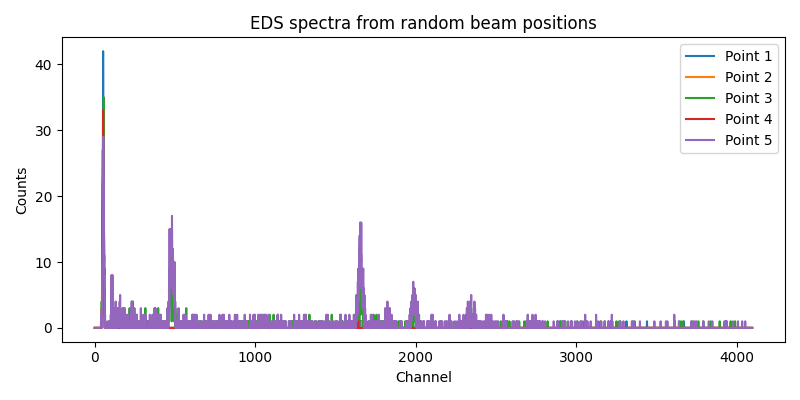

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
for record in spectra:
    ax.plot(record["spectrum"], label=f"Point {record['point_index']}")
ax.set_xlabel("Channel")
ax.set_ylabel("Counts")
ax.set_title("EDS spectra from random beam positions")
ax.legend()
plt.tight_layout()


### Configure and acquire an EDS spectrum


In [14]:
eds_proxy = tango.DeviceProxy("asyncroscopy/eds/default")
eds_proxy.exposure_time 

1.0

In [15]:
key = microscope.acquire_spectrum("eds")
node = client[key]["spectrum"]
spectrum = np.squeeze(np.asarray(node.read()))
metadata = dict(node.metadata)

print("Tiled key     :", key)
print("Metadata      :", metadata)
print("Spectrum shape:", spectrum.shape)
print("Spectrum dtype:", spectrum.dtype)


Tiled key     : spectrum_eds_20260529T123809491523.h5
Metadata      : {'AccelerationVoltage': '200000', 'AcquisitionDatetime': '2026-05-29T16:38:09.4824993Z', 'AcquisitionStartDatetime': '2026-05-29T16:38:07Z', 'Alpha': '9.9068e-05', 'ApplicationSoftware': 'AutoScript TEM', 'ApplicationSoftwareVersion': '1.15.0.484', 'AzimuthAngle': '0.785398163', 'AzimuthAngle_139': '2.35619449', 'AzimuthAngle_155': '3.92699082', 'AzimuthAngle_171': '5.49778714', 'BeamConvergence': '0.0299593314', 'BeamDiameter': '0', 'Begin': '0', 'Begin_108': '0.0173370261', 'Begin_116': '0.0728785469', 'C1LensIntensity': '-0.451997468', 'C2LensIntensity': '0.194833399', 'C3LensIntensity': '0.35410328', 'CameraLength': '0.091', 'CollectionAngle': '0.7', 'CollectionAngle_140': '0.7', 'CollectionAngle_156': '0.7', 'CollectionAngle_172': '0.7', 'ComputerName': 'TITAN52340180', 'ControlSoftwareVersion': '3.21.1', 'DarkGainCorrectionType': 'DarkGain', 'DarkGainCorrectionType_201': 'DarkGain', 'DarkGainCorrectionType_212'

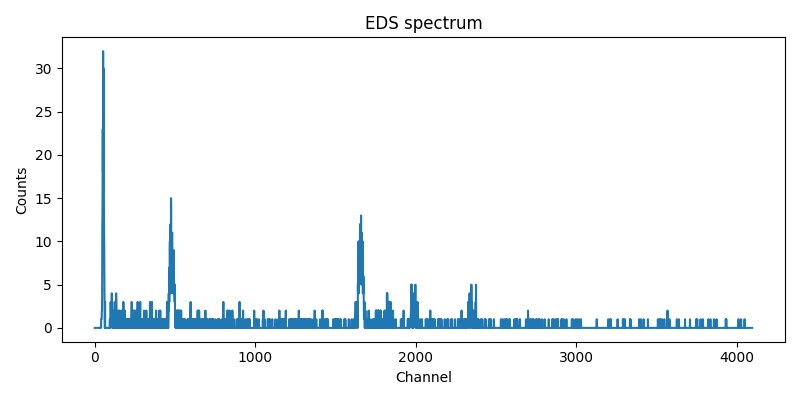

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(spectrum)
plt.xlabel("Channel")
plt.ylabel("Counts")
plt.title("EDS spectrum")
plt.tight_layout()

In [17]:
metadata

{'AccelerationVoltage': '200000',
 'AcquisitionDatetime': '2026-05-29T16:38:09.4824993Z',
 'AcquisitionStartDatetime': '2026-05-29T16:38:07Z',
 'Alpha': '9.9068e-05',
 'ApplicationSoftware': 'AutoScript TEM',
 'ApplicationSoftwareVersion': '1.15.0.484',
 'AzimuthAngle': '0.785398163',
 'AzimuthAngle_139': '2.35619449',
 'AzimuthAngle_155': '3.92699082',
 'AzimuthAngle_171': '5.49778714',
 'BeamConvergence': '0.0299593314',
 'BeamDiameter': '0',
 'Begin': '0',
 'Begin_108': '0.0173370261',
 'Begin_116': '0.0728785469',
 'C1LensIntensity': '-0.451997468',
 'C2LensIntensity': '0.194833399',
 'C3LensIntensity': '0.35410328',
 'CameraLength': '0.091',
 'CollectionAngle': '0.7',
 'CollectionAngle_140': '0.7',
 'CollectionAngle_156': '0.7',
 'CollectionAngle_172': '0.7',
 'ComputerName': 'TITAN52340180',
 'ControlSoftwareVersion': '3.21.1',
 'DarkGainCorrectionType': 'DarkGain',
 'DarkGainCorrectionType_201': 'DarkGain',
 'DarkGainCorrectionType_212': 'DarkGain',
 'Defocus': '-4.99290894e-07'